In [1]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

In [2]:
def W_dot(t, W, sigma, r, b):
    """
    Lorenz' equations
    Takes in a vector, returns the derivative of the vector (another vector)
    """
    X, Y, Z = W[0], W[1], W[2]
    X_dot = -sigma*(X-Y)
    Y_dot = r*X-Y-X*Z
    Z_dot = -b*Z + X*Y
    return [X_dot, Y_dot, Z_dot]

In [3]:
sigma=10.0
r=28.0
b=8/3
param = (sigma, r, b)
W0 = [0, 1, 0]
time_int = (0, 60)
sol = solve_ivp(W_dot, time_int, W0, args = param)
time = sol.t
X = sol.y[0]
Y = sol.y[1]
Z = sol.y[2]

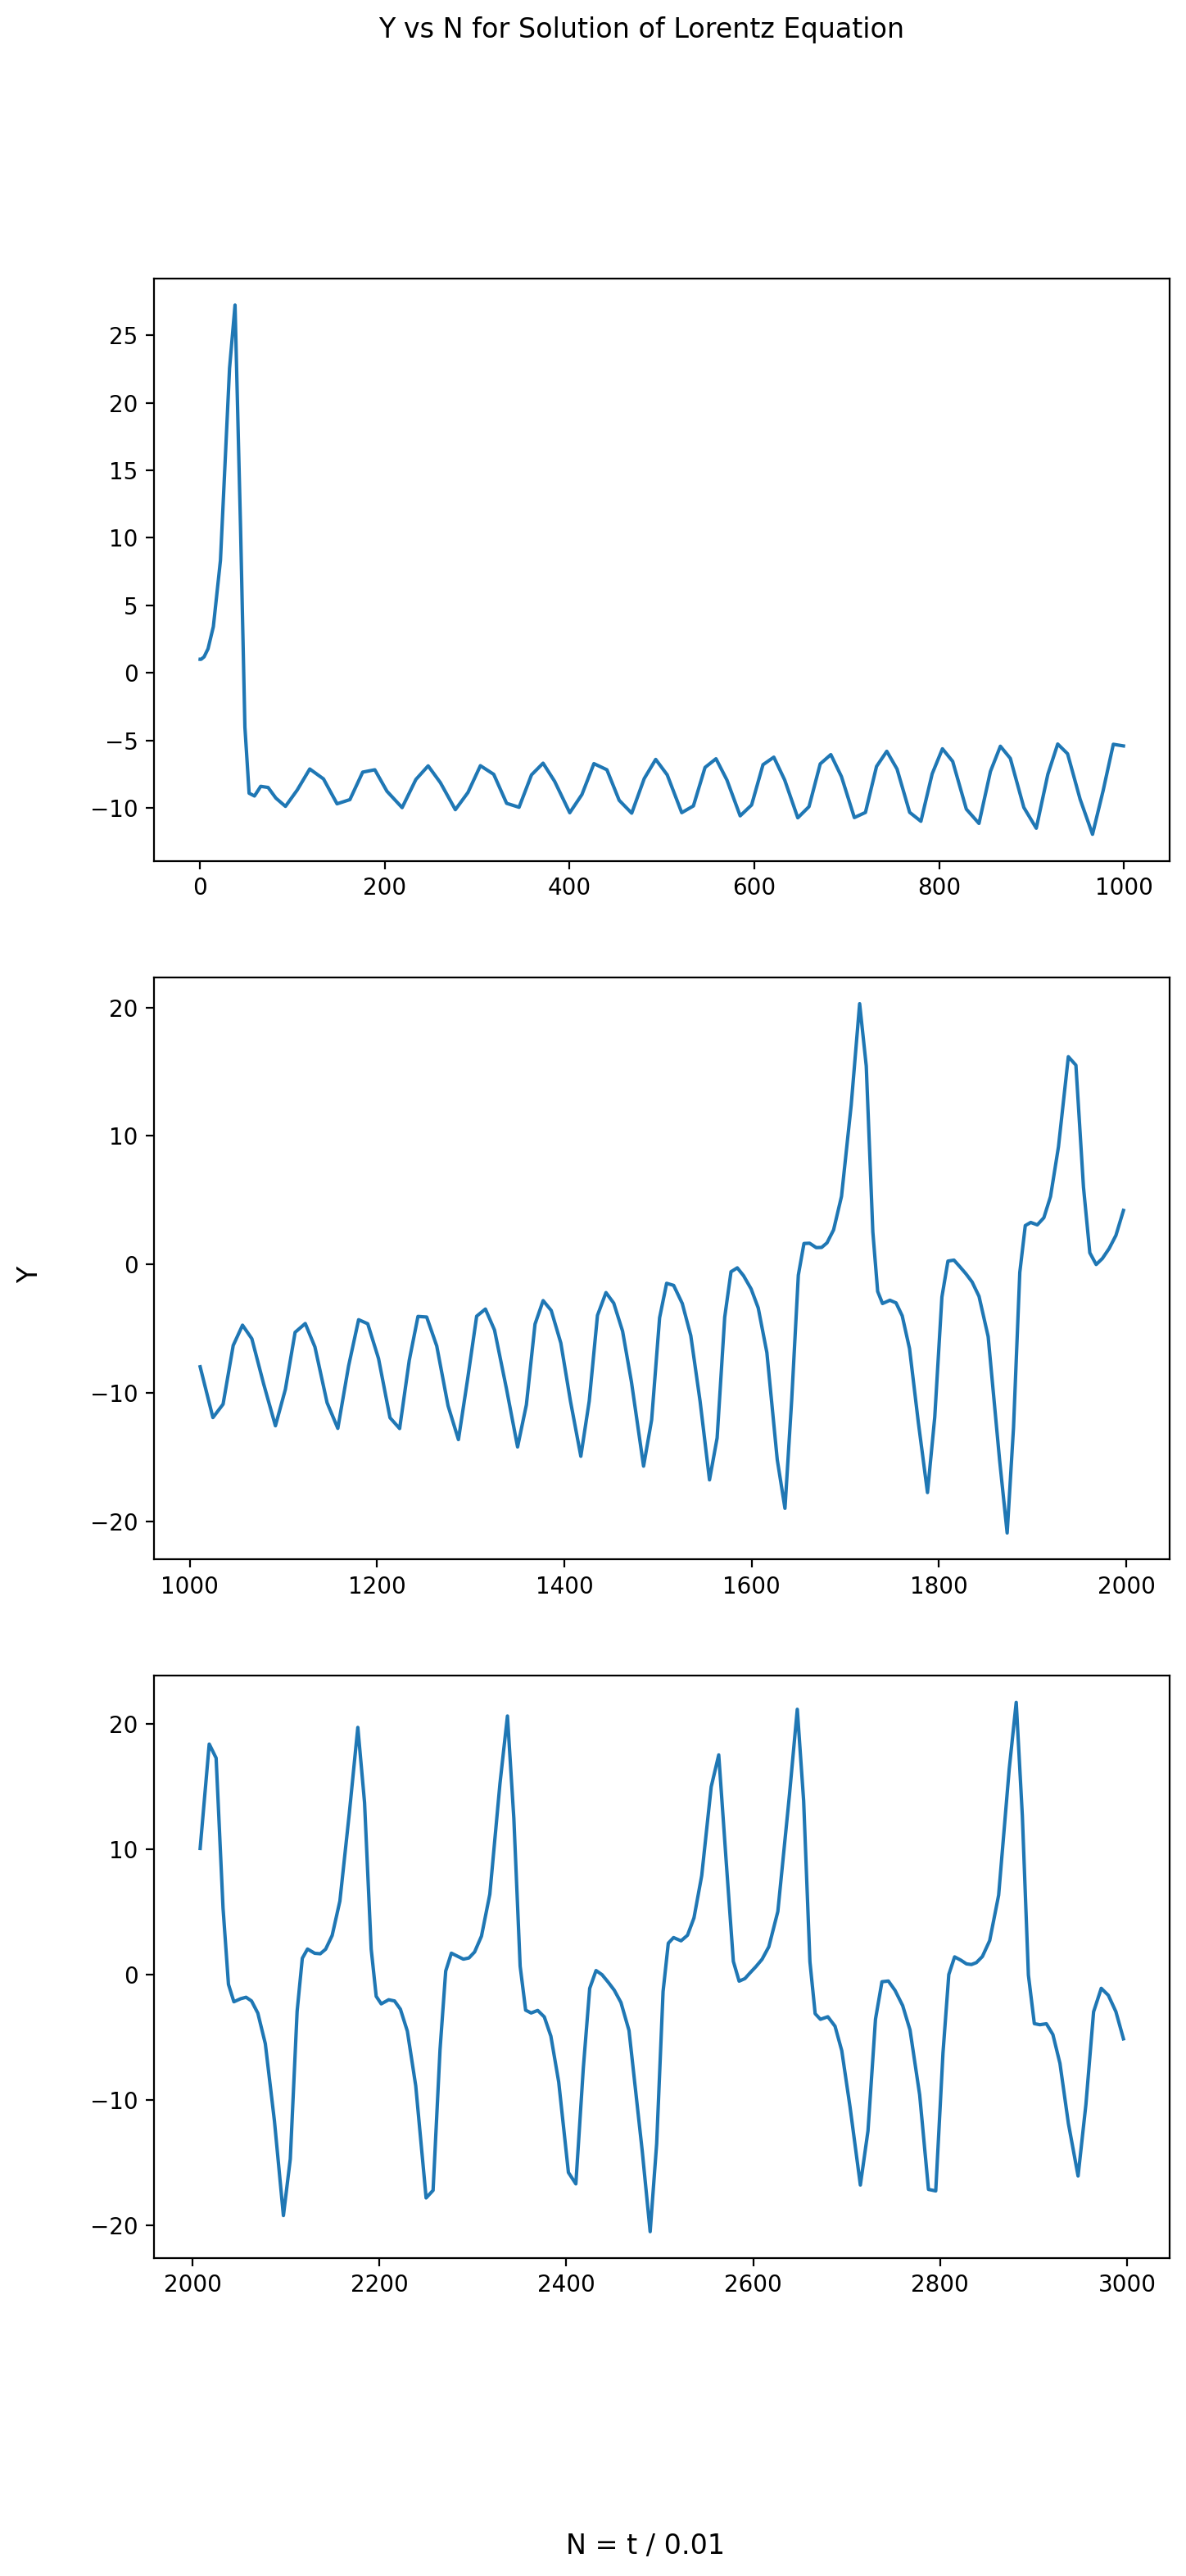

In [4]:
mask1 = (time/0.01 <= 1000) # Gets N < 1000 where N = t / delta t
mask2 = (time/0.01 <= 2000) & (time/0.01 > 1000)# Gets 1000 < N =< 2000 where N = t / delta t
mask3 = (time/0.01 <= 3000) & (time/0.01 > 2000)# Gets 2000 < N =< 3000 where N = t / delta t

fig, axs = plt.subplots(3, 1, figsize = (8, 16), dpi=200)
axs[0].plot(time[mask1]/0.01, Y[mask1])
axs[1].plot(time[mask2]/0.01, Y[mask2])
axs[2].plot(time[mask3]/0.01, Y[mask3])
fig.supxlabel(r"N = t / 0.01")
fig.supylabel('Y')
fig.suptitle('Y vs N for Solution of Lorentz Equation ' )
plt.show()

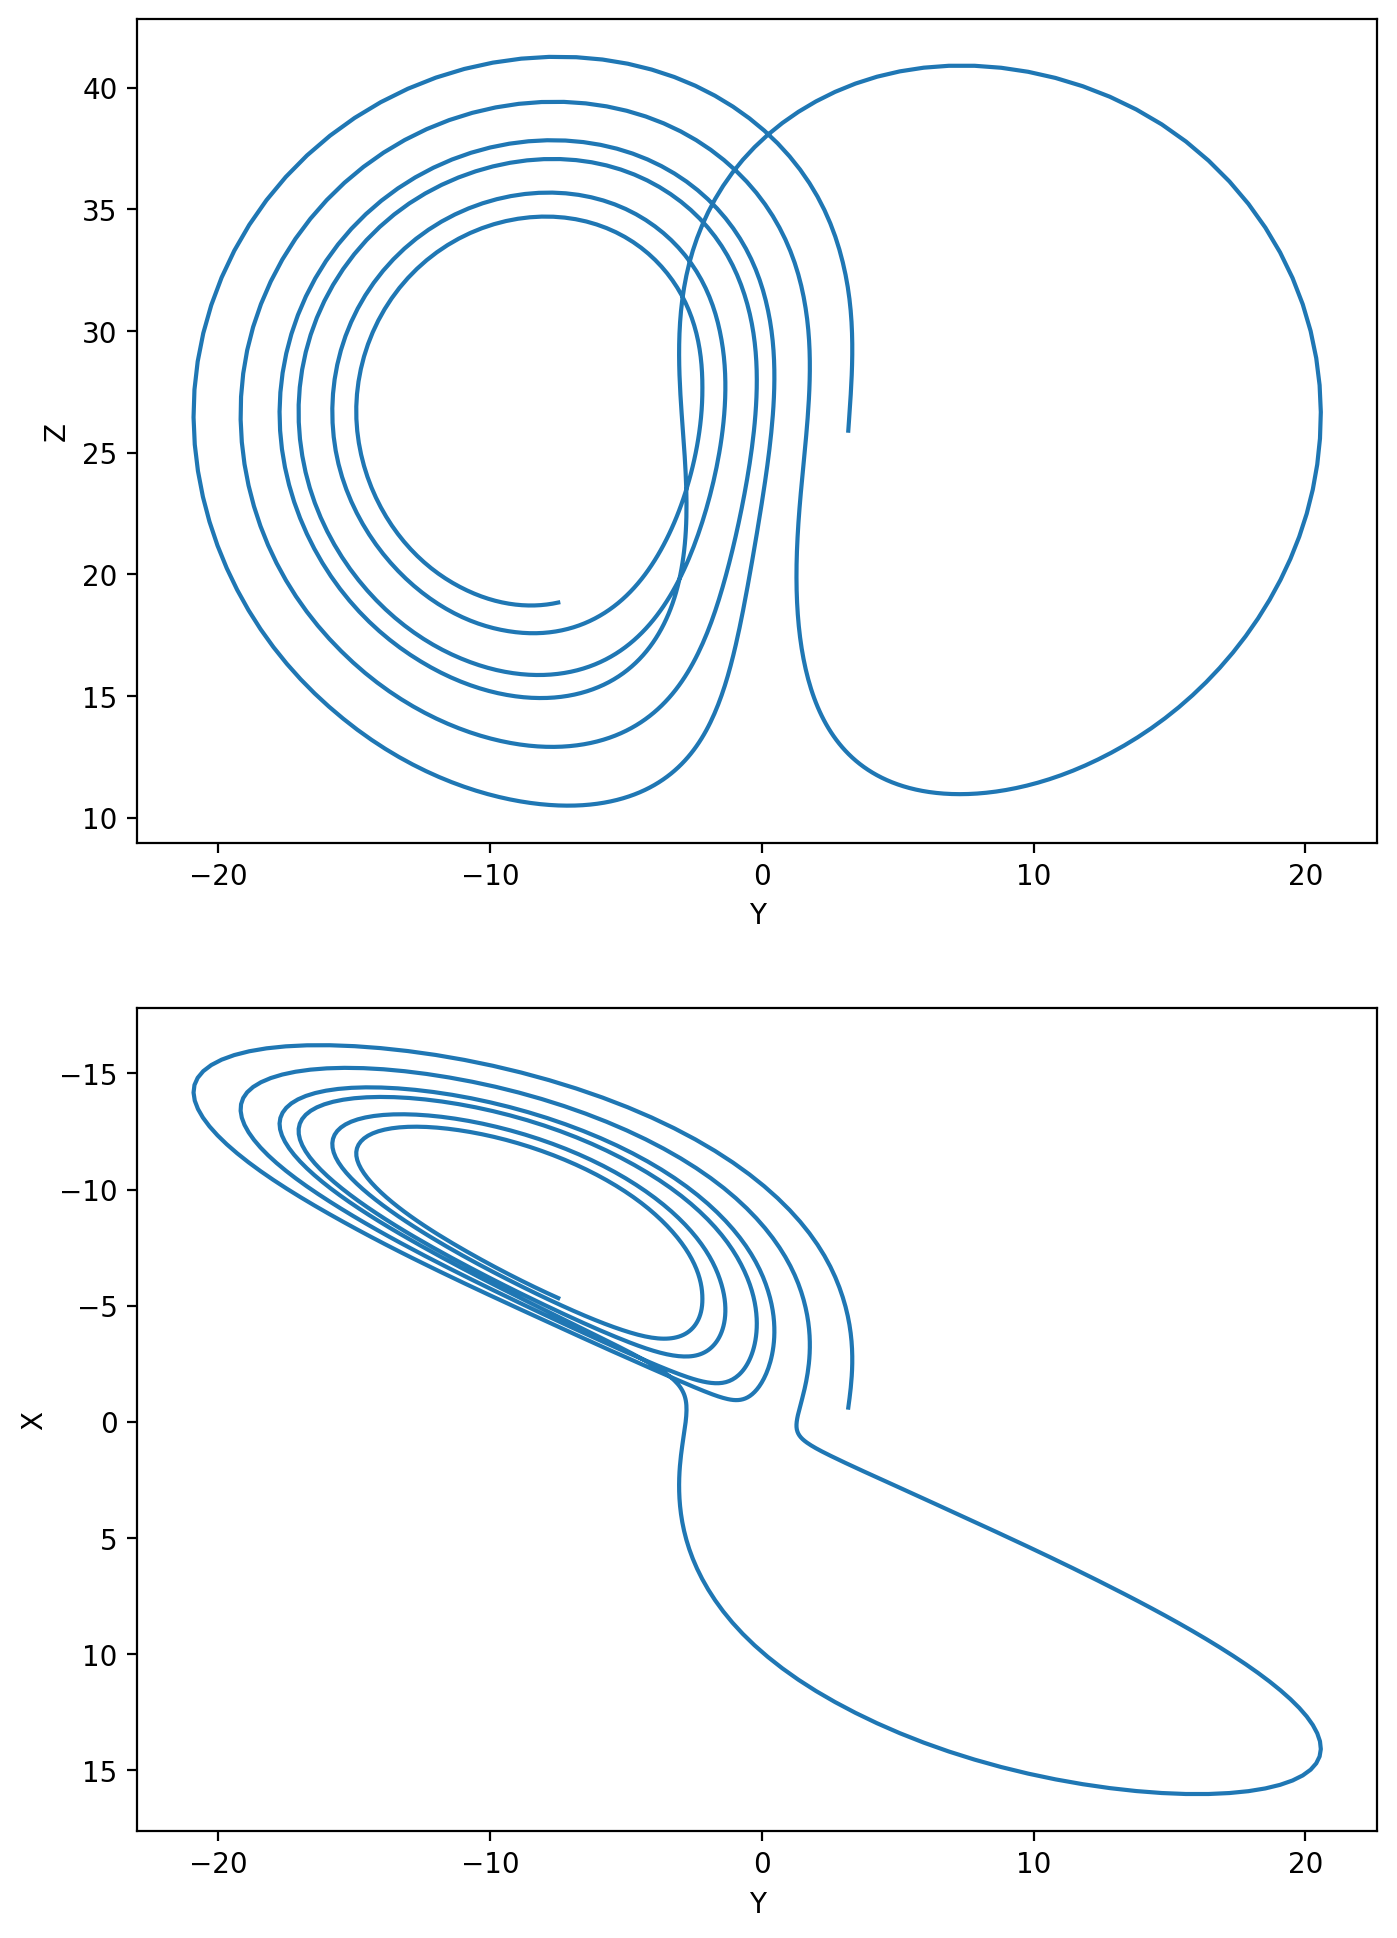

In [10]:
time_int = (0, 60)
t = np.linspace(14, 19, 1000)
sol = solve_ivp(W_dot, time_int, W0, t_eval=t, args = param)
W = sol.y
X, Y, Z = W[0], W[1], W[2]

fig, axs = plt.subplots(2, 1, figsize = (8, 12), dpi=200)
axs[0].plot(Y, Z)
axs[0].set_xlabel("Y")
axs[0].set_ylabel("Z")
axs[1].plot(Y, X)
axs[1].set_xlabel("Y")
axs[1].set_ylabel("X")
axs[1].invert_yaxis()
plt.show()

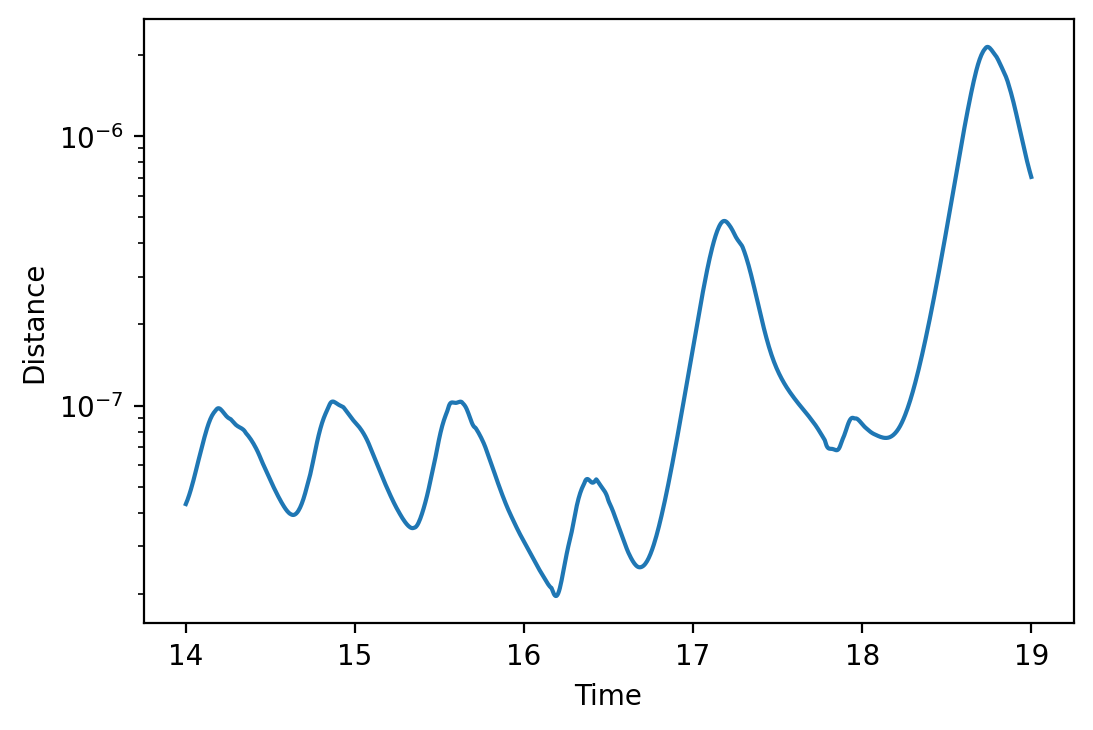

In [9]:
time_int = (0, 60)
t = np.linspace(14, 19, 1000)
W0 = [0, 1, 0]
W0_prime = np.asarray(W0) + np.array([0, 1e-8, 0])
sol_prime = solve_ivp(W_dot, time_int, W0_prime, t_eval=t, args = param)
W_prime = sol_prime.y
diff = W_prime - W #vectors
distance = np.linalg.norm(diff, axis=0)
plt.figure(figsize = (6, 4), dpi=200)
plt.semilogy(t, distance) #semilogy because log distance
plt.xlabel("Time")
plt.ylabel("Distance")
plt.show()